# Profile Coherence as a Diagnostic Lens for Financial Asset Recommendation

## Setup

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

ROOT = Path("..").resolve() if Path(".").resolve().name == "notebooks" else Path(".").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

EDA_DIRECTORY = ROOT / "outputs/eda"
RQ2_DIRECTORY = ROOT / "outputs/analysis/transaction_return_regression/20260504_004849"
RQ3_DECOMP_DIRECTORY = ROOT / "outputs/analysis/baseline_decomposition/20260427_122215"
RQ3_PANEL_DIRECTORY = ROOT / "outputs/analysis/panel_regression/20260504_003145"
RQ4_RESULTS_DIRECTORY = ROOT / "outputs/results/evaluation/pc_lgcn/20260505_125105"
RQ4_BASELINE_DIRECTORY = ROOT / "outputs/results/evaluation/light_gcn/20260427_122215/eb788_00006"

RISK_BAND_NAMES = {0: "Conservative", 1: "Income", 2: "Balanced", 3: "Aggressive"}
BAND_COLOURS = {
    "Conservative": "#1f77b4",
    "Income": "#2ca02c",
    "Balanced": "#ff7f0e",
    "Aggressive": "#d62728",
}

plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.4,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

with open(EDA_DIRECTORY / "summary.json") as fh:
    eda_summary = json.load(fh)

## Profile Coherence Metric

The metric is constructed via the following steps:

### Pairwise discordance

- `src/utils/profile_coherence.py` puts customers and assets on the **same 4-point ordinal scale**: `Conservative=0, Income=1, Balanced=2, Aggressive=3`
- **Customer band**:
    - Read from FAR-Trans's `riskLevel` column
    - Additional `is_predicted` flag for risk levels that are regression-imputed (`Predicted_*`)
    - Customers with `Not_Available` or missing `riskLevel` are excluded by assigning value of `b_u = None`
- **Asset band (hierarchical steps)**:
    1. Subcategory metadata first:
        - Mutual Funds subcategories:
            - Money Market -> Conservative
            - Bond/Bonds -> Income
            - Balanced -> Balanced
            - Equity/Large Cap -> Aggressive
        - Bond subcategories:
            - Government -> Conservative
            - Corporate -> Income
            - Other bonds - > Income (default)
    2. Volatility-quartile fallback for stocks:
        - A trailing 252-day annualised log-return std is computed per ISIN
        - The stock-only distribution gives `(q1, q2, q3)` and each stock is bucketed accordingly
    3. Balanced default:
        - Assets that fall through both rules (typically stocks without enough history) get Balanced
- **Pairwise discordance** then is `d(u, i) = |b_u - b_i| ∈ {0, 1, 2, 3}`
- A recommendation is **profile-coherent** iff `d ≤ 1`
- Strict variant `d == 0` is reported only as a sensitivity row

### Profile Coherence @k

- `src/utils/metrics.py` wraps the above into the `@k` aggregation:
    ```
    PC@k(u) = (1/k) · |{ i ∈ top_k(u) : d(u, i) ≤ 1 }|
    ```
- 3 implementation rules close the definition:
    1. **Truncation, not pad**:
        - A recommender returning fewer than `k` items is scored on what it returned
        - Replace `k` with the number of items recommended
    2. **Unclassifiable assets count as discordant**:
        - An `asset_id` missing from the band lookup contributes 0 to `coherent_count`
        - Should not occur due to the Balanced default
    3. **No-band customers contribute 0**:
        - Customers with `b_u = None` are excluded
        - Aggregate draws only on customers with a profile signal
- **PC@k for a split** is the unweighted mean of per-customer PC@k across eligible customers in that split
- Headline numerics then average over all splits

### Baseline Profile Coherence

- **Random baseline `pi(b)`** is computed directly from the asset-band distribution (`compute_random_baseline_per_band`):
    ```
    pi(b) = |{ i ∈ A : |b - b_i| ≤ 1 }| / |A|
    ```
- The closed-form expectation of PC@k under a uniformly random recommender per band
- For FAR-Trans:
    - Asset-band distribution `(190, 333, 105, 178)` of 806 assets
    - Over scale of `(Conservative, Income, Balanced, Aggressive)`
    - Results in `pi = (0.65, 0.78, 0.76, 0.35)`

### Profile Coherence - Lift @k

- **PC-lift@k** divides per-user PC@k by the band baseline: 
    ```
    PC-lift@k(u) = PC@k(u) / pi(b_u)
    ```
- The baseline profile coherence is skewed
- 77.9% of assets span the tolerated set of (`Conservative + Income + Balanced`)
- Hence if a recommender just shoves Income funds at everyone, it will score well on raw PC@k for the majority of users (whose band tolerance includes `Income`)
- PC-lift converts the raw PC@k into a scale-invariant metric
- Lift = 1.0 implies the model matched random sampling
- Lift > 1.0 implies the model beats the band-conditional random rate

## RQ1: Profile-discordance is prevalent and structural

**Question.** How prevalent is profile-discordance in observed FAR-Trans Buy transactions, and is it customer-level trait or transaction-level noise?

**Setup.** Each Buy transaction `(u, i)` is annotated with a customer band `b_u` and an asset band `b_i` using the rules described above. Recall that pairwise discordance is `d = |b_u - b_i|` and the transaction is profile-coherent under the default tolerance iff `d <= 1`.

Total scoreable Buys:      228,241
Coherent (d<=1) share:     81.4%
Strict-coherent (d=0):     34.1%
Mean profile discordance:  0.874 bands


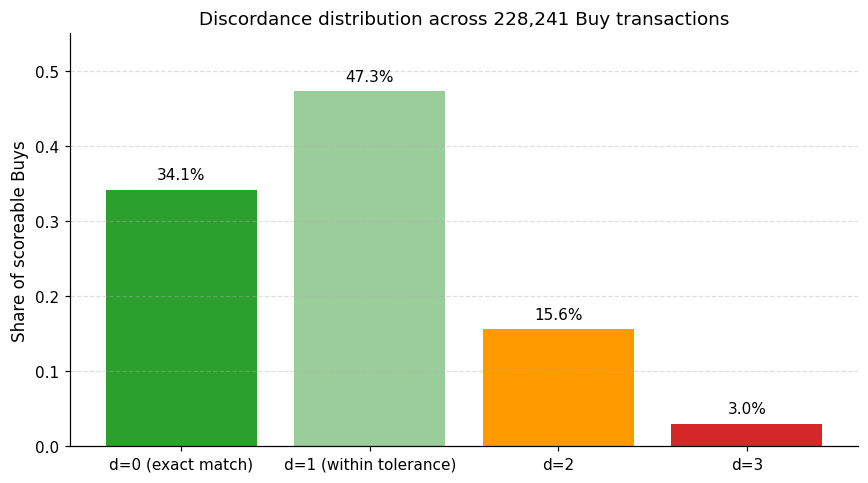

In [2]:
discordance = eda_summary["transaction_discordance_summary"]
counts = discordance["discordance_counts"]
total = discordance["transactions_with_both_bands"]

distribution = pd.DataFrame(
    [
        {"d": int(k), "count": v, "share": v / total}
        for k, v in counts.items()
    ]
).sort_values("d")

distribution["label"] = distribution["d"].map(
    {0: "d=0 (exact match)", 1: "d=1 (within tolerance)", 2: "d=2", 3: "d=3"}
)

print(
    f"Total scoreable Buys:      {total:,}\n"
    f"Coherent (d<=1) share:     {discordance['fraction_coherent_default']:.1%}\n"
    f"Strict-coherent (d=0):     {discordance['fraction_coherent_strict']:.1%}\n"
    f"Mean profile discordance:  {discordance['mean_discordance']:.3f} bands"
)

distribution[["label", "count", "share"]].rename(columns={"label": "discordance"}).style.format({"count": "{:,}", "share": "{:.1%}"})

fig, ax = plt.subplots()
colours = ["#2ca02c", "#9bcd9b", "#ff9900", "#d62728"]
ax.bar(distribution["label"], distribution["share"], color=colours)
for x, value in enumerate(distribution["share"]):
    ax.text(x, value + 0.01, f"{value:.1%}", ha="center", va="bottom")
ax.set_ylim(0, 0.55)
ax.set_ylabel("Share of scoreable Buys")
ax.set_title(f"Discordance distribution across {total:,} Buy transactions")
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

**Reading.**
- 81.4% of Buys are coherent under the default tolerance
- The remaining 18.6% (42,417 Buys) violate the declared MiFID band by 2 or more steps
- Notably 3.0% are extreme `d=3` mismatches
- Mean discordance is 0.87 bands
- Hence conclusion is that the typical violation is a one-band miss, but the distribution is heavy tailed

Population discordance rate (per Buy):                18.6%
Mean Buys per customer (with a known band):           7.93
Fully coherent customers   (every Buy in tolerance):  64.4%
Fully discordant customers (every Buy out of toler.): 17.2%
Majority-discordant share  (>50% of Buys discordant): 20.3%
Median discordant share    (50th-pct customer):       0.0%


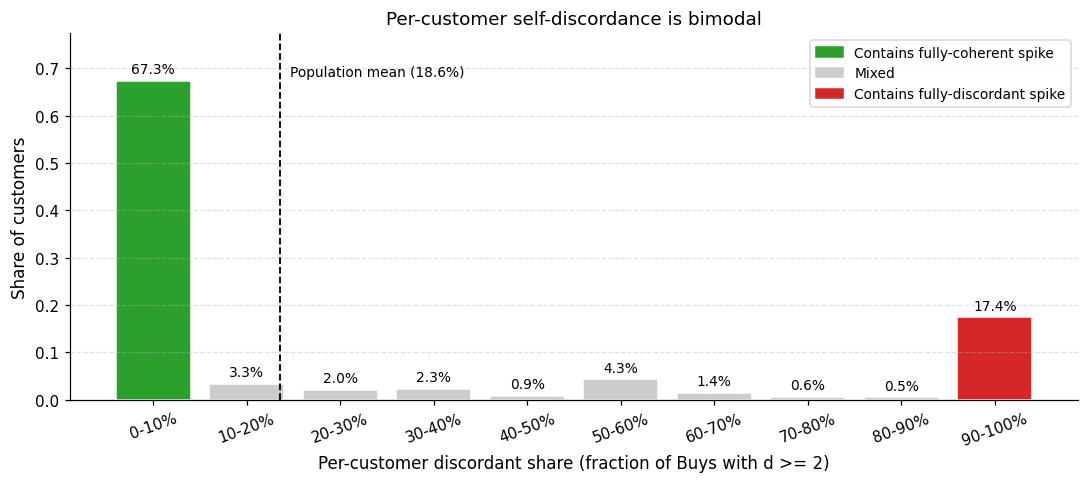

In [3]:
self_disc = eda_summary["customer_self_discordance_summary"]
populations = eda_summary["populations"]
transaction_summary = eda_summary["transaction_discordance_summary"]

population_discordance_rate = 1 - transaction_summary["fraction_coherent_default"]
mean_buys_per_scoreable_customer = (
    populations["transactions_with_both_bands"] / populations["customers_with_band"]
)

print(
    f"Population discordance rate (per Buy):                {population_discordance_rate:.1%}\n"
    f"Mean Buys per customer (with a known band):           {mean_buys_per_scoreable_customer:.2f}\n"
    f"Fully coherent customers   (every Buy in tolerance):  {self_disc['fraction_fully_coherent']:.1%}\n"
    f"Fully discordant customers (every Buy out of toler.): {self_disc['fraction_fully_discordant']:.1%}\n"
    f"Majority-discordant share  (>50% of Buys discordant): {self_disc['fraction_with_majority_discordance']:.1%}\n"
    f"Median discordant share    (50th-pct customer):       {self_disc['median_discordant_share']:.1%}"
)

edges = self_disc["discordant_share_histogram_edges"]
counts = np.array(self_disc["discordant_share_histogram_counts"], dtype=float)
total_customers = counts.sum()
shares = counts / total_customers
bin_labels = [f"{int(edges[i] * 100)}-{int(edges[i + 1] * 100)}%" for i in range(len(counts))]

bar_colours = ["#cccccc"] * len(counts)
bar_colours[0] = "#2ca02c"
bar_colours[-1] = "#d62728"

fig, ax = plt.subplots(figsize=(10, 4.5))
positions = np.arange(len(counts))
ax.bar(positions, shares, color=bar_colours, edgecolor="white")
for x, value in zip(positions, shares):
    ax.text(x, value + 0.01, f"{value:.1%}", ha="center", va="bottom", fontsize=9)

mean_x_position = population_discordance_rate * len(counts) - 0.5
ax.axvline(mean_x_position, color="black", linestyle="--", linewidth=1.2)
ax.text(
    mean_x_position + 0.1,
    max(shares) * 1.05,
    f"Population mean ({population_discordance_rate:.1%})\n",
    fontsize=9,
    va="top",
)

ax.set_xticks(positions)
ax.set_xticklabels(bin_labels, rotation=20)
ax.set_ylim(0, max(shares) * 1.15)
ax.set_ylabel("Share of customers")
ax.set_xlabel("Per-customer discordant share (fraction of Buys with d >= 2)")
ax.set_title(
    "Per-customer self-discordance is bimodal"
)
ax.grid(axis="x", visible=False)

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color="#2ca02c"),
    plt.Rectangle((0, 0), 1, 1, color="#cccccc"),
    plt.Rectangle((0, 0), 1, 1, color="#d62728"),
]
ax.legend(
    legend_handles,
    ["Contains fully-coherent spike", "Mixed", "Contains fully-discordant spike"],
    loc="upper right",
    fontsize=9,
)

plt.tight_layout()
plt.show()

**Reading.**
- The per-customer distribution is strongly bimodal piled at the two extreme 
- 64.4% of customers are **fully coherent** (every Buy has `d <= 1`)
- 17.2% are **fully discordant**(every Buy has `d >= 2`)
- Only 18.4% sit strictly between
- Profile-discordance is persistent within customers, not transaction-level noise, because the bimodal
  distribution shows customer shares piling up at 0% and 100% rather than clustering near the 19% population
  mean, which i.i.d. transaction-level noise cannot produce across customers averaging ~8 Buys each

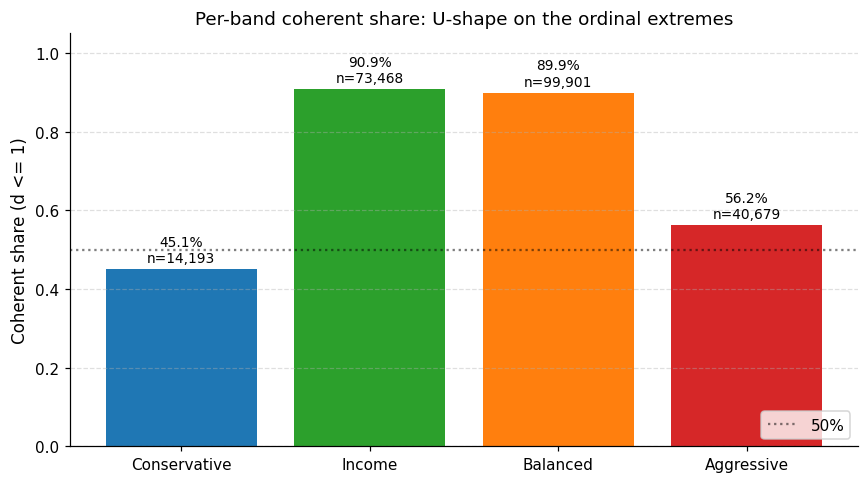

,band_label,transactions,coherent_share
2,Conservative,14193,45.1%
3,Income,73468,90.9%
1,Balanced,99901,89.9%
0,Aggressive,40679,56.2%


In [4]:
risk_level_counts = eda_summary["transaction_discordance_by_risk_level"]
band_rows = []
for band_label, by_d in risk_level_counts.items():
    total_band = sum(by_d.values())
    coherent_band = by_d.get("0", 0) + by_d.get("1", 0)
    band_rows.append({
        "band_label": band_label,
        "transactions": total_band,
        "coherent_share": coherent_band / total_band if total_band else 0,
    })
band_table = pd.DataFrame(band_rows)
band_order = ["Conservative", "Income", "Balanced", "Aggressive"]
band_table["band_label"] = pd.Categorical(band_table["band_label"], categories=band_order, ordered=True)
band_table = band_table.sort_values("band_label")

fig, ax = plt.subplots()
colours = [BAND_COLOURS[label] for label in band_table["band_label"]]
ax.bar(band_table["band_label"].astype(str), band_table["coherent_share"], color=colours)
for x, (count, share) in enumerate(zip(band_table["transactions"], band_table["coherent_share"])):
    ax.text(x, share + 0.01, f"{share:.1%}\nn={count:,}", ha="center", va="bottom", fontsize=9)
ax.axhline(0.5, linestyle=":", color="black", alpha=0.5, label="50%")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Coherent share (d <= 1)")
ax.set_title("Per-band coherent share: U-shape on the ordinal extremes")
ax.grid(axis="x", visible=False)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

band_table.assign(coherent_share=lambda d: d["coherent_share"].map("{:.1%}".format))

**Reading.**
- Discordance is concentrated on the two ordinal extremes
- Conservative customers are coherent on only 45.1% of their Buys (the rest are reach-for-yield purchases of riskier assets)
- Aggressive customers are coherent on 56.2% (regression-toward-the-centre into safer assets)
- The 2 centre bands (Income, Balanced) are roughly 90% coherent
- The U-shape supports the bimodality finding that Conservative reach-for-yield and Aggressive flight-to-safety features are what recommender will inherit unless the architecture is band-aware
- RQ1 serves as a empirical motivation for both the PC-lift normalisation (RQ3) and the band-stratified PC-LightGCN (RQ4)

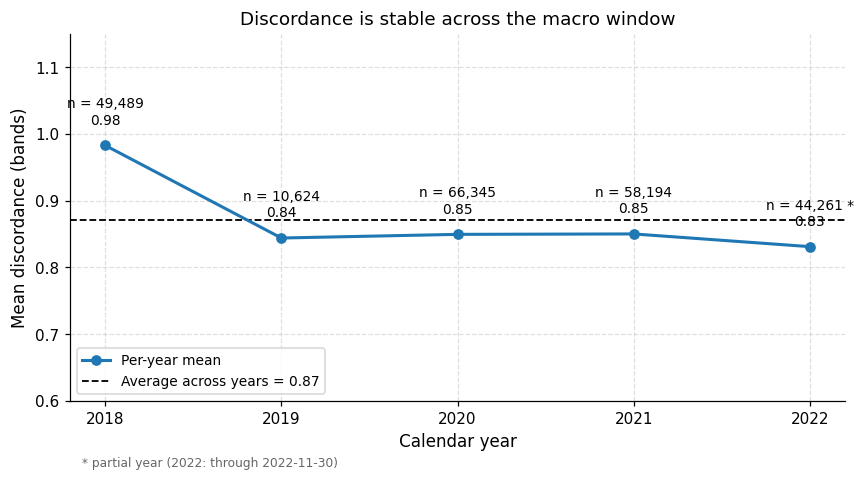

In [5]:
year_disc = eda_summary["mean_discordance_by_year"]
buy_coverage = eda_summary["buy_coverage_by_year"]
years = sorted(year_disc)
year_values = [year_disc[y] for y in years]
mean_across_years = float(np.mean(year_values))


def _is_partial_year(coverage):
    last = pd.Timestamp(coverage["last_date"])
    return (last.month, last.day) != (12, 31)


fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(years, year_values, marker="o", linewidth=2, color="#1f77b4", label="Per-year mean", zorder=3)
ax.axhline(
    mean_across_years,
    linestyle="--",
    color="black",
    linewidth=1.2,
    label=f"Average across years = {mean_across_years:.2f}",
)

for x, year in enumerate(years):
    coverage = buy_coverage[year]
    count = coverage["count"]
    partial_flag = " *" if _is_partial_year(coverage) else ""
    ax.annotate(
        f"n = {count:,}{partial_flag}\n{year_values[x]:.2f}",
        xy=(year, year_values[x]),
        xytext=(0, 12),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
    )

partial_years = [y for y in years if _is_partial_year(buy_coverage[y])]
caption = " * partial year (" + ", ".join(
    f"{y}: through {buy_coverage[y]['last_date']}" for y in partial_years
) + ")"
ax.text(0.01, -0.18, caption, transform=ax.transAxes, fontsize=8, color="#666666")

ax.set_ylim(0.6, 1.15)
ax.set_ylabel("Mean discordance (bands)")
ax.set_xlabel("Calendar year")
ax.set_title("Discordance is stable across the macro window")
ax.legend(loc="lower left", fontsize=9)

plt.tight_layout()
plt.show()

**Reading.**
- Mean discordance is flat across the macro window (average 0.87 bands; 2019-2022 cluster within 0.02 bands), so the pattern is not driven by a market regime or a one-off product push
- 2018 sits slightly higher (0.98 bands) but contributes a small slice of the dataset; from 2019 onwards the line is essentially horizontal
- **Caveat (2018 outlier hypothesis):** MiFID II came into force on 2018-01-03, the exact start of FAR-Trans. The 2018 elevation is consistent with a transition effect: risk profiles were being captured for the first time under the new framework, while customers were still trading under pre-MiFID habits formed without a declared band. By 2019 the system had a year of profile-aware history and the line settles
- Possible future extension of work

## RQ1 Findings Summary

Profile-discordance in FAR-Trans is:

- **Prevalent**: 18.6% of 228,241 scoreable Buys violate the declared MiFID band by 2 or more steps; 3.0% are extreme `d=3` mismatches (Conservative buying Aggressive or vice versa). Mean discordance is 0.87 bands
- **Customer-level, not transaction-level noise**: the per-customer discordant-share distribution is sharply bimodal (64.4% fully coherent, 17.2% fully discordant, only 18.4% in between). Mass piles up at 0% and 100% rather than clustering near the 19% population mean, which i.i.d. transaction-level noise cannot produce across customers averaging ~8 Buys each
- **Structurally concentrated on the ordinal extremes**: Conservative coherent share is 45.1% (reach-for-yield), Aggressive is 56.2% (regression-toward-the-centre), versus ~90% on the centre bands (Income, Balanced). The U-shape encodes two named behavioural-finance pathologies the recommender will inherit unless the architecture is band-aware
- **Stable across the macro window**: 2019-2022 cluster within 0.02 bands of each other, so the pattern is not regime-driven. The 2018 elevation (0.98 vs 0.84-0.85 from 2019-2022) is hypothesised as a MiFID II transition effect (regulation came into force 2018-01-03; first year of profile capture meets pre-MiFID trading habits) and flagged as future work

**Takeaway**: profile-discordance in FAR-Trans is a structural, customer-level, behaviourally-directional feature concentrated on exactly the two regulatory-extreme bands MiFID II was written to protect, and stable across the post-transition macro window. This is the empirical foundation that motivates all the subsequent research questions.

## RQ2: Profile-coherent transactions earn higher realised return

**Question.** Conditional on asset volatility, customer segment, and year, do profile-discordant transactions earn lower realised 6-month return than profile-coherent ones?

**Setup.** Each Buy is joined to a start price at its trade date and an end price 6 months later. Both prices are looked up via a backward-asof match against the close-price series with a 7-day tolerance (the most recent trading-day close within 7 calendar days), which handles weekends and holidays without future leakage and drops any row where the gap exceeds a week. The realised return is then `realised_return = (end_price - start_price) / start_price`. The model is

```
realised_return ~ is_coherent + asset_volatility + C(customer_type) + C(year)
```

with cluster-robust SE clustered on `customerID` (so the test treats customers, not individual Buys, as the independent units of variation).

**Test choice.** All p-values reported below are from **two-sided Wald tests** with a 95% confidence threshold (`alpha = 0.05`). Two-sided is the appropriate default because we have no directional prior on the controls (volatility, year, customer segment), and even for `is_coherent` a two-sided test keeps the analysis agnostic: a negative coefficient with `p < 0.05` would have falsified the hypothesis just as decisively as a positive one, so the test cannot be accused of baking the conclusion in. A coefficient is significant at 95% iff its 95% CI excludes zero, which is the same decision rule as `p < 0.05`.

In [6]:
coefficients = pd.read_csv(RQ2_DIRECTORY / "coefficients.csv")
with open(RQ2_DIRECTORY / "summary.json") as fh:
    rq2_summary = json.load(fh)

coherent_mean = rq2_summary["mean_realised_return_coherent"]
discordant_mean = rq2_summary["mean_realised_return_discordant"]
raw_slice_gap_pp = (coherent_mean - discordant_mean) * 100

print(
    f"Coherent share in panel:           {rq2_summary['coherent_share']:.3f}"
    f"     <- fraction of Buys in the regression panel with d<=1\n"
    f"Mean realised return (overall):    {rq2_summary['mean_realised_return_overall']:+.3%}"
    f"   <- 6-month forward return averaged across every Buy\n"
    f"Mean realised return (coherent):   {coherent_mean:+.3%}"
    f"   <- same average, restricted to coherent Buys (d<=1)\n"
    f"Mean realised return (discordant): {discordant_mean:+.3%}"
    f"   <- same average, restricted to discordant Buys (d>=2)\n"
    f"Raw slice gap (coh. - disc.):      {raw_slice_gap_pp:+.2f} pp"
    f"  <- unconditional difference, before any controls"
)

display_order = [
    "Intercept",
    "is_coherent",
    "asset_volatility",
    "C(customer_type)[T.Legal Entity]",
    "C(customer_type)[T.Mass]",
    "C(customer_type)[T.Premium]",
    "C(customer_type)[T.Professional]",
    "C(year)[T.2019]",
    "C(year)[T.2020]",
    "C(year)[T.2021]",
    "C(year)[T.2022]",
]
term_explanations = {
    "Intercept": "Baseline = Inactive customer, 2018, all numeric regressors = 0",
    "is_coherent": "Coherence premium after controlling for vol, segment, year",
    "asset_volatility": "Return penalty per 1.0 unit of annualised vol (negative = low-vol won)",
    "C(customer_type)[T.Legal Entity]": "Segment effect vs Inactive reference",
    "C(customer_type)[T.Mass]": "Segment effect vs Inactive reference",
    "C(customer_type)[T.Premium]": "Segment effect vs Inactive reference",
    "C(customer_type)[T.Professional]": "Segment effect vs Inactive reference",
    "C(year)[T.2019]": "Calendar effect vs 2018 reference (pre-COVID equity recovery)",
    "C(year)[T.2020]": "Calendar effect vs 2018 reference (COVID rebound)",
    "C(year)[T.2021]": "Calendar effect vs 2018 reference (continued post-COVID recovery)",
    "C(year)[T.2022]": "Calendar effect vs 2018 reference (bond / rate-shock drawdown)",
}
filtered = coefficients[coefficients["term"].isin(display_order)].copy()
filtered = filtered.set_index("term").reindex(display_order).reset_index()


def fmt_p(p):
    if p < 1e-3:
        return f"{p:.1e}"
    return f"{p:.4f}"


filtered_display = filtered.assign(
    estimate=lambda d: d["estimate"].map("{:+.4f}".format),
    std_error=lambda d: d["std_error"].map("{:.4f}".format),
    ci=lambda d: d.apply(
        lambda r: f"[{r['ci_lower']:+.4f}, {r['ci_upper']:+.4f}]", axis=1
    ),
    p_value=lambda d: d["p_value"].map(fmt_p),
    meaning=lambda d: d["term"].map(term_explanations),
)

print(
    f"\nFull regression has {len(coefficients)} estimated terms; "
    f"References: 2018 (year), Inactive (customer_type), absorbed into the Intercept."
)

filtered_display[["term", "estimate", "std_error", "ci", "p_value", "meaning"]]


Coherent share in panel:           0.813     <- fraction of Buys in the regression panel with d<=1
Mean realised return (overall):    +3.614%   <- 6-month forward return averaged across every Buy
Mean realised return (coherent):   +4.232%   <- same average, restricted to coherent Buys (d<=1)
Mean realised return (discordant): +0.925%   <- same average, restricted to discordant Buys (d>=2)
Raw slice gap (coh. - disc.):      +3.31 pp  <- unconditional difference, before any controls

Full regression has 11 estimated terms; References: 2018 (year), Inactive (customer_type), absorbed into the Intercept.


,term,estimate,std_error,ci,p_value,meaning
0,Intercept,-0.0471,0.0141,"[-0.0746, -0.0195]",8.1e-04,"Baseline = Inactive customer, 2018, all numeri..."
1,is_coherent,+0.0294,0.0040,"[+0.0215, +0.0372]",2.3e-13,"Coherence premium after controlling for vol, s..."
2,asset_volatility,-0.1025,0.0165,"[-0.1349, -0.0701]",5.5e-10,Return penalty per 1.0 unit of annualised vol ...
3,C(customer_type)[T.Legal Entity],+0.0154,0.0486,"[-0.0798, +0.1106]",0.7512,Segment effect vs Inactive reference
4,C(customer_type)[T.Mass],+0.0011,0.0132,"[-0.0248, +0.0269]",0.9362,Segment effect vs Inactive reference
5,C(customer_type)[T.Premium],+0.0058,0.0135,"[-0.0206, +0.0322]",0.6671,Segment effect vs Inactive reference
6,C(customer_type)[T.Professional],+0.0247,0.0169,"[-0.0084, +0.0578]",0.1434,Segment effect vs Inactive reference
7,C(year)[T.2019],+0.1759,0.0129,"[+0.1507, +0.2012]",1.4e-42,Calendar effect vs 2018 reference (pre-COVID e...
8,C(year)[T.2020],+0.2107,0.0061,"[+0.1986, +0.2227]",6.2e-259,Calendar effect vs 2018 reference (COVID rebound)
9,C(year)[T.2021],+0.0754,0.0053,"[+0.0651, +0.0858]",4.1e-46,Calendar effect vs 2018 reference (continued p...


**Reading.**

- **p-values let us reject H0 for every term except customer_type**:
    - Under the two-sided Wald test at `alpha = 0.05`, the null hypothesis for each row is `H0: coefficient = 0` (the term has no effect on 6-month realised return)
    - **Reject H0** for:
        - `is_coherent` (p = 2.3e-13)
        - `asset_volatility` (p = 5.5e-10)
        - All four year dummies (p in [1.4e-05, 6.2e-259])
        - Intercept (p = 8.1e-04)
    - **Fail to reject H0** for:
        - All four `C(customer_type)` dummies (p in [0.14, 0.94])
    - Read the rest of the bullets through that lens: which terms moved the dial, and which didn't
- **Coherence premium (`is_coherent`) = +2.94 pp / 6 months**:
    - Estimate: profile-coherent Buys earn +2.94 percentage points more realised 6-month return than profile-discordant ones, after controlling for volatility, customer segment, and year
    - SE: cluster-robust, clustered on `customerID` (treats customers, not Buys, as the independent units)
    - 95% CI: [+2.15, +3.72] pp (excludes zero, significant at 95%)
    - Two-sided p = 2.3e-13 (~7.3 sigma, roughly four orders of magnitude past the particle-physics 5-sigma threshold)
- **Robust to the controls**:
    - Raw slice gap: +3.31 pp (unconditional `mean(coherent) - mean(discordant)`)
    - Conditional estimate: +2.94 pp (after vol/segment/year controls)
    - Controls absorb only ~0.4 pp of the unconditional gap
    - ~89% of the raw gap survives, so the residual is not a vol/segment/year artefact masquerading as a coherence effect
- **Year fixed effects pick up the macro window, as expected**:
    - 2018 is the reference year (folded into the intercept)
    - 2019: +18 pp (pre-COVID equity recovery)
    - 2020: +21 pp (COVID rebound)
    - 2021: +8 pp (continued recovery)
    - 2022: -1.9 pp (bond / rate-shock drawdown)
    - `asset_volatility` coefficient: -0.103 (low-vol assets outperformed across the sample window)
    - All five terms are significant, so the controls are doing real work; the surviving +2.94 pp coherence premium is more credible against this backdrop
- **Customer-type effects are statistically indistinguishable from zero**:
    - Inactive is the reference category (folded into the intercept)
    - Mass: estimate +0.001, p = 0.94
    - Premium: estimate +0.006, p = 0.67
    - Professional: estimate +0.025, p = 0.14
    - Legal Entity: estimate +0.015, p = 0.75
    - All four 95% CIs cross zero, so we **fail to reject H0** for every customer-type dummy
    - After conditioning on volatility, coherence, and year there is no residual segment effect to explain
    - Consistent with the earlier decision to drop the segment chart from RQ1
- **Economically meaningful, not just statistically detectable**:
    - +2.94 pp on a 6-month horizon is roughly +6 pp annualised
    - Same order of magnitude as the asset-volatility penalty
    - Dwarfs the (non-significant) customer-type effects, which are all under 0.03

## RQ2 Findings Summary

The model `realised_return ~ is_coherent + asset_volatility + C(customer_type) + C(year)`, fit on 208,029 priced Buys with cluster-robust SE on `customerID`, yields:

- **Coherence premium**: +2.94 pp / 6 months conditional on the controls (95% CI [+2.15, +3.72] pp; two-sided p = 2.3e-13, ~7.3 sigma)
- **Robust to controls**: ~89% of the +3.31 pp raw slice gap survives the controls; only ~0.4 pp is absorbed by volatility, segment, and year, so the residual is not a confound
- **Macro window is properly absorbed**: all four year dummies are significant (2020 +21 pp COVID rebound, 2022 -1.9 pp rate shock), volatility coefficient is -0.103; the controls are doing real work behind the surviving coherence premium
- **No residual segment effect**: all four `C(customer_type)` dummies fail to reject H0 (p in [0.14, 0.94]); after conditioning on vol/coherence/year there is no segment story left to tell
- **Economically meaningful**: +2.94 pp on a 6-month horizon is roughly +6 pp annualised, the same order of magnitude as the asset-volatility penalty and an order of magnitude larger than the (non-significant) customer-type effects

**Takeaway**:
- On FAR-Trans, profile-coherent Buys are positively associated with realised return, conditional on volatility, segment, and year (+2.94 pp / 6 months, 95% CI [+2.15, +3.72] pp, p = 2.3e-13)
- The association is observational and the mechanism is not established, but the sign and magnitude are enough to falsify the "regulatory tax" prior and to motivate the model-side investigations in RQ3 and RQ4

## RQ3: Both FAR-Trans baselines under-serve declared-band coherence

**Question.** Where do the FAR-Trans baselines (Random Forest, LightGCN) sit on the PC@10 axis, and does any baseline match or exceed the band-conditional random baseline `pi(b)` for every declared band?

**Setup.** Each baseline is tuned on its FAR-Trans primary metric (LightGCN: nDCG@10, Random Forest: ROI@10) over a grid of 8/12 trials respectively, evaluated on 69 monthly temporal splits between Aug 2019 and Apr 2025. The model panel regression `coherent_share ~ C(declared_band) * C(model) + C(split_index)` is fit with cluster-robust SE on `customer_id`; predicted PC@10 is reported at the median split (36).

In [7]:
main_results = pd.read_csv(RQ3_DECOMP_DIRECTORY / "main_results.csv")
display_columns = [
    "display_name", "best_trial_id", "primary_metric",
    "ndcg_at_k_mean", "roi_at_k_mean", "recall_at_k_mean",
    "profile_coherence_at_k_mean", "profile_coherence_lift_at_k_mean",
]
main_results_display = main_results[display_columns].rename(columns={
    "display_name": "Model",
    "best_trial_id": "Best trial",
    "primary_metric": "Primary metric",
    "ndcg_at_k_mean": "nDCG@10",
    "roi_at_k_mean": "ROI@10 (mo.)",
    "recall_at_k_mean": "Recall@10",
    "profile_coherence_at_k_mean": "PC@10",
    "profile_coherence_lift_at_k_mean": "PC-lift@10",
})
main_results_display.style.format({
    "nDCG@10": "{:.3f}",
    "ROI@10 (mo.)": "{:+.4f}",
    "Recall@10": "{:.3f}",
    "PC@10": "{:.3f}",
    "PC-lift@10": "{:.3f}",
})

,Model,Best trial,Primary metric,nDCG@10,ROI@10 (mo.),Recall@10,PC@10,PC-lift@10
0,LightGCN,eb788_00006,average_ndcg,0.330,-0.0054,0.495,0.794,1.171
1,Random Forest,df0bd_00008,average_roi,0.019,+0.0142,0.036,0.667,1.060


**Reading.**

- LightGCN takes the top spot on ranking-quality metrics (nDCG@10 = 0.330, Recall@10 = 0.495, PC@10 = 0.794) but loses on realised return (ROI = -0.5%/mo)
- Random Forest takes the top spot on ROI (+1.4%/mo) but ranks near random on nDCG (0.019) and Recall (0.036)
- **Both models look fine on the aggregate PC axis**: LightGCN PC-lift@10 = 1.17x random, Random Forest PC-lift@10 = 1.06x random; both above 1.0
- But aggregate PC averages across customer bands with very different `pi(b)` baselines (0.35 to 0.78), so the aggregate hides which bands are actually being served. The per-band table below decomposes that

In [8]:
predicted_pc = pd.read_csv(RQ3_PANEL_DIRECTORY / "predicted_pc_by_band_model.csv")
asset_band_dist = eda_summary["asset_band_distribution_by_category"]
total_per_band = {band: 0 for band in RISK_BAND_NAMES.values()}
for category, band_counts in asset_band_dist.items():
    for band_label, count in band_counts.items():
        total_per_band[band_label] += count
total_assets = sum(total_per_band.values())
band_to_idx = {label: idx for idx, label in RISK_BAND_NAMES.items()}
pi = {}
for band_idx, label in RISK_BAND_NAMES.items():
    coherent_count = sum(
        total_per_band[other_label] for other_idx, other_label in RISK_BAND_NAMES.items()
        if abs(other_idx - band_idx) <= 1
    )
    pi[label] = coherent_count / total_assets
pi_series = pd.Series(pi).reindex(["Conservative", "Income", "Balanced", "Aggressive"])

bands_order = ["Conservative", "Income", "Balanced", "Aggressive"]
predicted_pc["band_label"] = pd.Categorical(predicted_pc["band_label"], categories=bands_order, ordered=True)
predicted_pc = predicted_pc.sort_values(["model_display", "band_label"])

summary = predicted_pc[["band_label", "model_display", "predicted_pc", "ci_lower", "ci_upper"]].copy()
summary["band_label"] = summary["band_label"].astype(str)
summary["pi_b"] = summary["band_label"].map(pi_series.to_dict())
summary["lift"] = (summary["predicted_pc"] / summary["pi_b"]).round(3)
summary

,band_label,model_display,predicted_pc,ci_lower,ci_upper,pi_b,lift
0,Conservative,LightGCN,0.519793,0.496011,0.543575,0.648883,0.801
2,Income,LightGCN,0.919189,0.914625,0.923753,0.779156,1.180
4,Balanced,LightGCN,0.925527,0.920979,0.930074,0.764268,1.211
6,Aggressive,LightGCN,0.508232,0.496900,0.519564,0.351117,1.447
1,Conservative,Random Forest,0.374281,0.368424,0.380138,0.648883,0.577
3,Income,Random Forest,0.579047,0.576162,0.581932,0.779156,0.743
5,Balanced,Random Forest,0.820926,0.818348,0.823503,0.764268,1.074
7,Aggressive,Random Forest,0.696772,0.693239,0.700305,0.351117,1.984


**Reading.**

- **Both baselines actively introduce discordance on the regulator-critical bands instead of adding signal**:
    - On the regulator-critical bands, a uniformly-random recommender beats both models
    - LightGCN falls below `pi(b)` on Conservative (0.520 vs 0.649, lift 0.80x)
    - Random Forest falls below on Conservative (0.374, lift 0.58x) AND Income (0.579, lift 0.74x)
    - Above-random elsewhere, but on the bands that drive the regulatory case both subtract signal rather than add it
- **The failing bands cover 60.9% of all banded customers**:
    - Conservative: 19.7% of 28,770 banded customers
    - Income: 41.1%
    - Combined: 60.9%, ~6 in 10 of the served population
    - That 6-in-10 is precisely the population MiFID II was written to protect
- **Random Forest's ROI advantage is concentrated on Aggressive**:
    - Aggressive is only 9.3% of the customer base
    - Random Forest over-serves it at 1.99x random coverage
    - So Random Forest's headline ROI is earned on the smallest declared segment via riskier-than-tolerated recommendations
    - **What 1.99x actually tells us**: Random Forest puts ~2x as many recommendations within Aggressive tolerance as random. Sounds good alone, but paired with sub-random Conservative (0.58x) and Income (0.74x), it reveals Random Forest is not band-aware: it pushes the same high-profitability (and structurally risky) assets to everyone, and Aggressive customers are the only band whose tolerance overlaps that bias
- **LightGCN shows the same directional failure as Random Forest, just less extreme**:
    - Per-band lift profile: Conservative 0.80x, Income 1.18x, Balanced 1.21x, Aggressive 1.45x
    - Same monotonic shape as Random Forest (0.58, 0.74, 1.07, 1.99) but compressed: one sub-random band vs Random Forest's two, milder Aggressive over-service (1.45x vs 1.99x)
    - Different mechanism: LightGCN (BPR on the buy graph) learns what customers actually bought. Conservative buys are 45% coherent (reach-for-yield), so LightGCN reproduces that pathology in recommendations. Income/Balanced/Aggressive buys are 90% / 90% / 56% coherent, so recommendations to those bands mostly land in-tolerance
    - Why less extreme than Random Forest: LightGCN's user-item graph carries *some* band-implicit signal (81% of buys are coherent overall); Random Forest's profitability target carries *zero* band signal by construction, so the band failure is sharper

In [9]:
decomp = pd.read_csv(RQ3_DECOMP_DIRECTORY / "decomposition.csv")
decomp_display = decomp[[
    "display_name", "coherent_share",
    "mean_monthly_return_coherent", "mean_monthly_return_discordant",
    "mean_monthly_return_overall",
]].rename(columns={
    "display_name": "Model",
    "coherent_share": "Coherent share",
    "mean_monthly_return_coherent": "Coherent ROI/mo",
    "mean_monthly_return_discordant": "Discordant ROI/mo",
    "mean_monthly_return_overall": "Overall ROI/mo",
})
decomp_display.style.format({
    "Coherent share": "{:.3f}",
    "Coherent ROI/mo": "{:+.4%}",
    "Discordant ROI/mo": "{:+.4%}",
    "Overall ROI/mo": "{:+.4%}",
})

,Model,Coherent share,Coherent ROI/mo,Discordant ROI/mo,Overall ROI/mo
0,LightGCN,0.794,-0.8419%,-0.5389%,-0.7795%
1,Random Forest,0.665,+1.6708%,+0.8000%,+1.3788%


**Reading.**

- **LightGCN inverts the RQ2 customer-side sign on its own recommendations**:
    - Coherent slice ROI: -0.84%/mo
    - Discordant slice ROI: -0.54%/mo
    - Coherent slice underperforms discordant by 0.30 pp/mo
- **Random Forest preserves the RQ2 sign**:
    - Coherent slice ROI: +1.67%/mo
    - Discordant slice ROI: +0.80%/mo
    - Coherent slice beats discordant by 0.87 pp/mo, matching the RQ2 direction at the model level
- **The divergence comes from what each model is trained on**:
    - **LightGCN**: trained on the customer-asset buy graph (BPR loss), never sees prices or returns, so its "coherent" recommendations have no inherent reason to be profitable. The coherent slice underperforms because the training objective is uncorrelated with the return axis
    - **Random Forest**: trained on price time series and technical indicators with forward 6-month return as the target, so it directly ranks by predicted profitability. The coherent slice beats the discordant one because safer assets outperformed in the 2019-2022 macro window AND safer assets are within tolerance for most customers (60.9% are Conservative or Income), so profitability and coherence accidentally aligned

## RQ3 Findings Summary

Locating the two FAR-Trans baselines (Random Forest, LightGCN) at their primary-metric optima on the PC@10 axis, with a band-conditional random baseline `pi(b)` and a coherent/discordant ROI decomposition:

- **Aggregate PC@10 is misleading**: both models clear the random baseline on average (LightGCN PC-lift = 1.17x, Random Forest PC-lift = 1.06x), but the aggregate is dominated by the bands with the highest `pi(b)` (Income at 0.78) and hides the per-band failures
- **Both baselines actively introduce discordance on the regulator-critical bands**: LightGCN is sub-random on Conservative (0.80x); Random Forest is sub-random on both Conservative (0.58x) and Income (0.74x). The failing bands together cover 60.9% of customers with a known band, so this is structural under-service, not a niche failure
- **The failure has different mechanisms in each model**:
    - Random Forest is trained on price + technical indicators with forward return as the target, so it ranks the same risky-but-profitable assets for everyone; this matches Aggressive tolerance (1.99x lift) but fails Conservative and Income
    - LightGCN is trained on the customer-asset buy graph (BPR loss) and reproduces the RQ1 U-shape: Conservative customers historically reach-for-yield, so LightGCN learns to recommend riskier assets to them, hence sub-random Conservative coverage
- **Random Forest's headline ROI advantage is structurally fragile**: +1.4%/mo on aggregate, but the win is concentrated on Aggressive (9.3% of customers, 1.99x random coverage). Random Forest is earning the headline on the smallest declared segment by aligning with riskier-than-tolerated assets, not by serving the bands the regulation protects
- **Random Forest preserves the RQ2 customer-side sign by accident; LightGCN inverts it**:
    - Random Forest's coherent slice beats its discordant slice by +0.87 pp/mo because profitability and within-tolerance accidentally aligned in this macro window (safer assets outperformed)
    - LightGCN's coherent slice underperforms its discordant slice by 0.30 pp/mo because its training objective has no profitability signal at all
    - **Evidence that safer assets outperformed in the sample window**: RQ2's `asset_volatility` coefficient is **-0.103** (95% CI [-0.135, -0.070], p = 5.5e-10) on 208,029 priced Buys; higher annualised volatility maps to lower 6-month forward return, with the 2022 year fixed effect at -1.9 pp also confirming the risk-off tilt of the window
    - Neither model recovers the RQ2 premium structurally; one alignment is regime-dependent and the other is absent

**Takeaway**:
- At their primary-metric optima, the existing FAR-Trans baselines under-serve declared-band coherence precisely on the customer bands MiFID II was designed to protect (Conservative for both, Income for Random Forest), and the failure is hidden by aggregate metrics that weight toward the bands with the most generous random baselines
- Neither baseline recovers the customer-side coherence premium from RQ2 for the right reason: Random Forest gets the sign by regime-dependent accident (grounded in RQ2's negative volatility coefficient), LightGCN inverts it. This is the model-side coverage deficit that motivates RQ4: can a band-stratified, profile-coherent architecture close the per-band gap without giving up the return premium that the data says is already there?

## RQ4: Stratification + profile-coherent loss closes the per-band coverage deficit

**Question.** Can a stratified, profile-coherent LightGCN extension (one sub-model per declared MiFID risk band, trained with a profile-coherent margin loss) improve PC@10 over the global LightGCN baseline, and at what cost to nDCG, Recall, and ROI?

**Setup.** Two trials with the same backbone hyperparameters as the RQ3 best LightGCN trial (`embedding_dimension = 64, number_of_layers = 3, learning_rate = 1e-3, weight_decay = 1e-5, keep_probability = 0.6, number_of_epochs = 50, batch_size = 1024`):
- **`stratified_lambda_0.0`** (ablation): four band-stratified sub-models, BPR loss only.
- **`stratified_lambda_1.0`** (treatment): four band-stratified sub-models with an added profile-coherent margin loss `softplus(score_discordant - score_coherent)` weighted by `lambda = 1`.

**Choice of backbone.** LightGCN trains with a differentiable loss and carries per-customer embeddings, so the coherence margin can be added on top. Random Forest has no customer signal in its training objective (asset-level technical indicators only), so the analogous extension does not exist.

**Loss composition.** The profile-coherent margin is **added on top of** the existing BPR ranking loss, not a replacement: `total_loss = bpr_loss + weight_decay * l2 + lambda * coherence_loss`. Setting `lambda = 0` zeroes the coherence term and reduces the model to stratified BPR (the ablation), so both trials keep BPR as the primary ranking signal and only the treatment trial activates the coherence term.

Both evaluated on the same 69 splits as RQ3, so per-split deltas are paired against the global LightGCN baseline (`eb788_00006`).

In [10]:
from IPython.display import display


def load_per_split(path: Path, label: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["trial"] = label
    return df


baseline_per_split = load_per_split(RQ4_BASELINE_DIRECTORY / "per_split_metrics.csv", "baseline")
lambda0_per_split = load_per_split(RQ4_RESULTS_DIRECTORY / "stratified_lambda_0.0/per_split_metrics.csv", "lambda_0")
lambda1_per_split = load_per_split(RQ4_RESULTS_DIRECTORY / "stratified_lambda_1.0/per_split_metrics.csv", "lambda_1")
metric_columns = ["ndcg_at_k", "roi_at_k", "recall_at_k", "profile_coherence_at_k", "profile_coherence_lift_at_k"]

aggregate = pd.DataFrame({
    "Configuration": ["LightGCN baseline (RQ3)", "Stratified, λ=0 (ablation)", "Stratified, λ=1 (treatment)"],
    "nDCG@10": [
        baseline_per_split["ndcg_at_k"].mean(),
        lambda0_per_split["ndcg_at_k"].mean(),
        lambda1_per_split["ndcg_at_k"].mean(),
    ],
    "ROI@10 (mo.)": [
        baseline_per_split["roi_at_k"].mean(),
        lambda0_per_split["roi_at_k"].mean(),
        lambda1_per_split["roi_at_k"].mean(),
    ],
    "Recall@10": [
        baseline_per_split["recall_at_k"].mean(),
        lambda0_per_split["recall_at_k"].mean(),
        lambda1_per_split["recall_at_k"].mean(),
    ],
    "PC@10": [
        baseline_per_split["profile_coherence_at_k"].mean(),
        lambda0_per_split["profile_coherence_at_k"].mean(),
        lambda1_per_split["profile_coherence_at_k"].mean(),
    ],
    "PC-lift@10": [
        baseline_per_split["profile_coherence_lift_at_k"].mean(),
        lambda0_per_split["profile_coherence_lift_at_k"].mean(),
        lambda1_per_split["profile_coherence_lift_at_k"].mean(),
    ],
})

print("=== Aggregate metrics: mean across 69 evaluation splits, per configuration ===")
display(aggregate.style.format({
    "nDCG@10": "{:.4f}",
    "ROI@10 (mo.)": "{:+.4f}",
    "Recall@10": "{:.4f}",
    "PC@10": "{:.4f}",
    "PC-lift@10": "{:.3f}",
}))


def paired_summary(treatment: pd.DataFrame, control: pd.DataFrame, label: str) -> pd.DataFrame:
    rows = []
    for column in metric_columns:
        delta = treatment[column].to_numpy() - control[column].to_numpy()
        win_rate = (delta > 0).mean()
        rows.append({
            "contrast": label,
            "metric": column,
            "mean_delta": delta.mean(),
            "win_rate": win_rate,
        })
    return pd.DataFrame(rows)


paired_table = pd.concat([
    paired_summary(lambda0_per_split, baseline_per_split, "λ=0 vs baseline"),
    paired_summary(lambda1_per_split, baseline_per_split, "λ=1 vs baseline"),
    paired_summary(lambda1_per_split, lambda0_per_split, "λ=1 vs λ=0 (PC-loss)"),
], ignore_index=True)

pretty_metric = {
    "ndcg_at_k": "nDCG@10",
    "roi_at_k": "ROI@10 (mo.)",
    "recall_at_k": "Recall@10",
    "profile_coherence_at_k": "PC@10",
    "profile_coherence_lift_at_k": "PC-lift@10",
}
paired_table["metric"] = paired_table["metric"].map(pretty_metric)

paired_display = paired_table.assign(
    mean_delta=lambda d: d["mean_delta"].map("{:+.5f}".format),
    win_rate=lambda d: d["win_rate"].map("{:.0%}".format),
)

print(
    "\n=== Paired per-split contrasts ===\n"
    "mean_delta  = average of (treatment - control) across the 69 splits\n"
    "win_rate    = fraction of splits where treatment > control (delta > 0)\n"
    "Three contrasts:\n"
    "  - λ=0 vs baseline       : isolates the stratification effect (BPR only, no PC-loss)\n"
    "  - λ=1 vs baseline       : the full intervention (stratification + PC-loss)\n"
    "  - λ=1 vs λ=0 (PC-loss)  : isolates the PC-loss effect under matched architecture"
)

display(paired_display.pivot(
    index="contrast",
    columns="metric",
    values=["mean_delta", "win_rate"],
))

=== Aggregate metrics: mean across 69 evaluation splits, per configuration ===


,Configuration,nDCG@10,ROI@10 (mo.),Recall@10,PC@10,PC-lift@10
0,LightGCN baseline (RQ3),0.3295,-0.0054,0.4946,0.7940,1.171
1,"Stratified, λ=0 (ablation)",0.3317,-0.0073,0.5009,0.8215,1.189
2,"Stratified, λ=1 (treatment)",0.3094,-0.0071,0.4671,0.9182,1.396



=== Paired per-split contrasts ===
mean_delta  = average of (treatment - control) across the 69 splits
win_rate    = fraction of splits where treatment > control (delta > 0)
Three contrasts:
  - λ=0 vs baseline       : isolates the stratification effect (BPR only, no PC-loss)
  - λ=1 vs baseline       : the full intervention (stratification + PC-loss)
  - λ=1 vs λ=0 (PC-loss)  : isolates the PC-loss effect under matched architecture


mean_delta                                             \
metric               PC-lift@10     PC@10 ROI@10 (mo.) Recall@10   nDCG@10   
contrast                                                                     
λ=0 vs baseline        +0.01875  +0.02745     -0.00191  +0.00626  +0.00222   
λ=1 vs baseline        +0.22594  +0.12422     -0.00175  -0.02750  -0.02011   
λ=1 vs λ=0 (PC-loss)   +0.20719  +0.09676     +0.00015  -0.03376  -0.02233   

                       win_rate                                       
metric               PC-lift@10 PC@10 ROI@10 (mo.) Recall@10 nDCG@10  
contrast                                                              
λ=0 vs baseline             90%  100%          28%       72%     57%  
λ=1 vs baseline            100%  100%          33%        7%      7%  
λ=1 vs λ=0 (PC-loss)       100%  100%          58%        0%      0%

**Reading.**

- **The treatment (λ=1) wins PC@10 universally and by a large margin**:
    - Aggregate PC@10 climbs from 0.794 (baseline) to 0.918 (+12.4 pp)
    - PC-lift@10 climbs from 1.17x to 1.40x random
    - Win rate is 100% on both PC@10 and PC-lift@10: λ=1 beats the baseline on every single one of the 69 splits
- **Stratification alone (λ=0) is essentially free signal**:
    - λ=0 vs baseline: PC@10 +0.027 (100% wins), Recall +0.006 (72% wins), nDCG +0.002 (57% wins)
    - Splitting the model by band lifts band-coverage even without the PC-loss, with no ranking-quality cost
    - Contributes ~22% of the full λ=1 PC@10 gain (+2.7 pp out of +12.4 pp)
- **The PC-loss is the expensive but high-payoff piece**:
    - λ=1 vs λ=0: PC@10 +0.097 (100% wins), Recall -0.034 (0% wins), nDCG -0.022 (0% wins)
    - Buys +9.7 pp PC@10 at the bounded cost of ~2 pp nDCG and ~3 pp Recall
    - Contributes ~78% of the full λ=1 PC@10 gain (+9.7 pp out of +12.4 pp)
    - The gain decomposes cleanly: stratification supplies the cheap quarter, the PC-loss supplies the rest
- **Aggregate ROI is essentially flat, and the small penalty is not from the PC-loss**:
    - Full intervention (λ=1 vs baseline): ROI -0.002 pp/mo (33% wins), a tiny drop
    - Stratification alone (λ=0 vs baseline): ROI -0.002 pp/mo (28% wins), same drop
    - PC-loss alone (λ=1 vs λ=0): ROI +0.0001 pp/mo (58% wins), indistinguishable from noise
    - So the small aggregate ROI cost lives in stratification, not in the coherence loss

## Conclusion